In [1]:
import numpy as np
from network import *
from GNAR import *
from GNARID import *
import matplotlib.pyplot as plt
import time
from time import time
from tqdm import tqdm
seed=19

# Illustration of idw

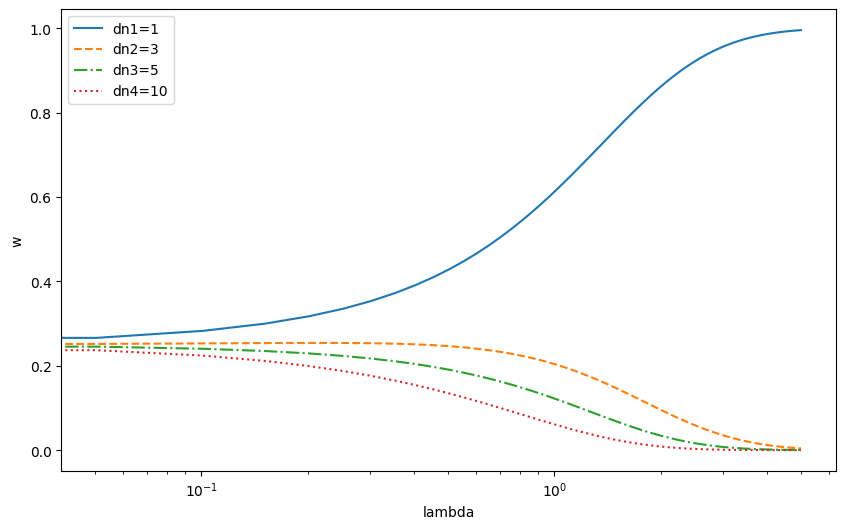

In [2]:
def BC(x,gammas):
    return np.array([x**-gamma/np.sum(x**-gamma) for gamma in gammas])

gammas = np.linspace(0,5,100)
x = np.array([1,3,5,10])
w = BC(x,gammas)
linestyles = ["-","--","-.",":"]
plt.figure(figsize=(10,6))
for i in range(4):
    plt.semilogx(gammas,w[:,i],label="dn"+str(i+1)+"="+str(x[i]),linestyle=linestyles[i])
plt.xlabel("lambda")
plt.ylabel("w")
plt.legend()

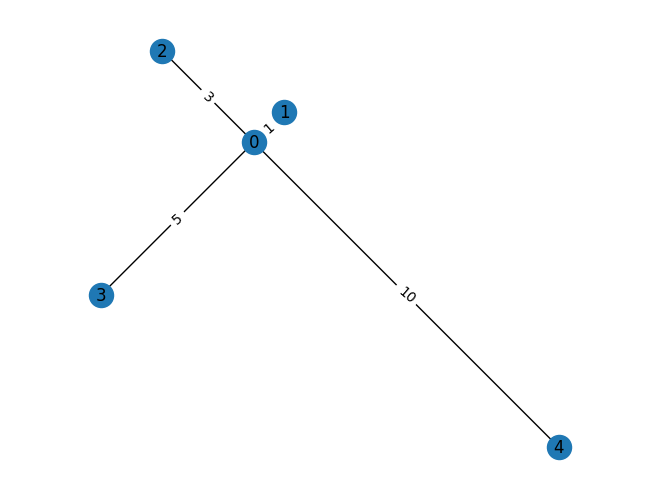

In [3]:
import networkx as nx

x = np.array([1, 3, 5, 10])

G = nx.star_graph(len(x))

angles = np.linspace(0, 2*np.pi, len(x), endpoint=False) + np.pi/4

pos = {0: (0, 0)}
for i, d in enumerate(x, start=1):
    pos[i] = (d*np.cos(angles[i-1]), d*np.sin(angles[i-1]))

nx.draw(G, pos, with_labels=True)

edge_labels = {(0, i): x[i-1] for i in range(1, len(x)+1)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis("equal")
plt.show()

# Simulation

In [6]:
def random_network_dist(N):
    edges = {}
    dists = {}
    indices = [i for i in range(N)]
    for i in range(N):
        indices.remove(i)
        edges[i] = random.sample(indices,random.randint(int(N/4),int(N/4*3)))
        indices.append(i)
        dists[i] = np.random.exponential(size=len(edges[i]))
    return Network(edges,dists,symmetry=False)

In [7]:
def random_cov_matrix(n, a=0.1,seed=None):
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((n, n))
    S = A @ A.T
    return S * (n * a / np.trace(S))

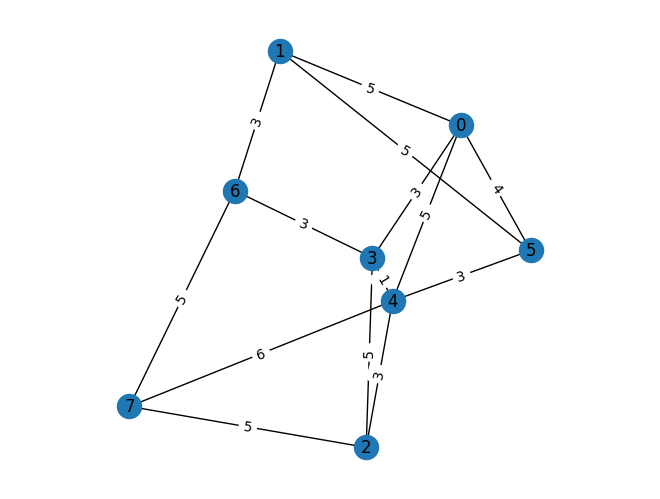

In [4]:
import networkx as nx

edges = {
    0: [1, 3, 4],
    1: [0, 6],
    2: [3, 4],
    3: [2, 4],
    4: [0, 2],
    5: [0, 1, 4],
    6: [3],
    7: [4, 6, 2],
}

dists = {
    0: np.array([5, 3, 5]),
    1: np.array([4, 3]),
    2: np.array([5, 3]),
    3: np.array([4, 1]),
    4: np.array([3, 4]),
    5: np.array([4, 5, 3]),
    6: np.array([3]),
    7: np.array([6, 5, 5]),
}

G = nx.Graph()

for i in edges:
    for j, d in zip(edges[i], dists[i]):
        if not G.has_edge(i, j):
            G.add_edge(i, j, distance=d)

pos = nx.kamada_kawai_layout(G, weight="distance")

nx.draw(G, pos, with_labels=True)

edge_labels = nx.get_edge_attributes(G, "distance")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.axis("equal")
plt.show()

## Case A

In [396]:
n8_14 = n8_14=Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=3.)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 1, [1], [np.array([0.35,0.55])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(1,[1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|███████████████████████████████████| 1000/1000 [06:06<00:00,  2.73it/s, coefs=[0.32985685 0.55823096], gamma=2.96]

3.007077077077077
0.213717663997549
[0.3498224  0.54945867]
[0.00904061 0.01131017]


## Case B

In [395]:
n8_14 = Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=3.)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|█████████| 1000/1000 [07:38<00:00,  2.18it/s, coefs=[ 0.32887352  0.26133174  0.14413504 -0.20968601], gamma=2.64]

3.0535035035035034
0.530421067805413
[ 0.34993302  0.25002117  0.14979727 -0.20024293]
[0.01084382 0.01850595 0.01084197 0.01801457]


## Case C

In [397]:
n8_14 = n8_14=Network(edges={0:[1,3,4],1:[0,6],2:[3,4],3:[2,4],4:[0,2],5:[0,1,4],6:[3],7:[4,6,2]},
                      dists ={0:np.array([5,3,5]),1:np.array([4,3]),2:np.array([5,3]),3:np.array([4,1]),4:np.array([3,4]),5:np.array([4,5,3]),6:np.array([3]),7:np.array([6,5,5])}, symmetry=True, gamma=.6)
gammas = []
coefses = []
progress_bar = tqdm(range(1000))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n8_14], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[0.1*np.identity(8)], [1000], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n8_14,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|█████████| 1000/1000 [09:08<00:00,  1.82it/s, coefs=[ 0.32845636  0.27571364  0.1438219  -0.21707738], gamma=0.38]

0.5876976976976976
0.21123290928401098
[ 0.34991733  0.24979322  0.1497218  -0.19956545]
[0.01088119 0.02056837 0.0109493  0.0205745 ]


## Appendix Case A

In [324]:
random.seed(seed)
np.random.seed(seed)
n64 = random_network_dist(64)
n64.UpdateGamma(3.)
cov = random_cov_matrix(64,0.1,seed)
gammas = []
coefses = []
progress_bar = tqdm(range(100))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n64], 1, [1], [np.array([0.35,0.55])], False,True,[cov], [200], burn_in = 100) 
    g = GNARID(1,[1],intercept=False)
    g.fit(n64,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|█████████████████████████████████████| 100/100 [06:38<00:00,  3.98s/it, coefs=[0.36479615 0.52981715], gamma=3.12]

2.9979979979979974
0.14136813613710783
[0.34882515 0.55000854]
[0.0093781  0.00985115]


## Appendix Case B

In [327]:
random.seed(seed)
np.random.seed(seed)
n64 = random_network_dist(64)
n64.UpdateGamma(3.)
cov = random_cov_matrix(64,0.1,seed)
gammas = []
coefses = []
progress_bar = tqdm(range(100))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n64], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[cov], [200], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n64,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|███████████| 100/100 [09:02<00:00,  5.43s/it, coefs=[ 0.38052315  0.24145255  0.13336052 -0.20594353], gamma=2.95]

3.0361361361361356
0.36964649385908455
[ 0.34915485  0.25044538  0.15111919 -0.2016316 ]
[0.01188064 0.01174876 0.01209406 0.01084696]


## Appendix Case C

In [328]:
random.seed(seed)
np.random.seed(seed)
n64 = random_network_dist(64)
n64.UpdateGamma(.6)
cov = random_cov_matrix(64,0.1,seed)
gammas = []
coefses = []
progress_bar = tqdm(range(100))
for _ in progress_bar:
    np.random.seed(_)
    vts_sim= GNAR_sim_piecewise([n64], 2, [1,1], [np.array([0.35,0.25,0.15,-0.2])], False,True,[cov], [200], burn_in = 100) 
    g = GNARID(2,[1,1],intercept=False)
    g.fit(n64,vts_sim,grid_search=True)
    gammas.append(g.gamma)
    coefses.append(g.coefs)
    progress_bar.set_postfix(coefs=coefses[-1], gamma=gammas[-1])
print(np.mean(gammas))
print(np.std(gammas))
print(np.mean(coefses,axis=0))
print(np.std(coefses,axis=0))

100%|██████████| 100/100 [09:09<00:00,  5.49s/it, coefs=[ 0.38050306  0.26592295  0.13410685 -0.25088158], gamma=0.521]

0.6051051051051051
0.09235692216798702
[ 0.34913986  0.25403009  0.15101483 -0.20409431]
[0.01206661 0.04092913 0.01218363 0.03534504]


# Misspecification

## GNAR vs GNARID

In [4]:
def misspecification_sim(size,gamma,coef,network_redraw=True):
    mses_g = []
    mses_g_bc = []
    if not network_redraw:
        n_ran = random_network_dist(size)
        n_ran_gamma = deepcopy(n_ran)
        n_ran_gamma.UpdateGamma(gamma)
    progress_bar = tqdm(range(1000))
    for _ in progress_bar:
        np.random.seed(_)
        random.seed(_)
        if network_redraw:
            n_ran = random_network_dist(size)
            n_ran_gamma = deepcopy(n_ran)
            n_ran_gamma.UpdateGamma(gamma)
        vts_sim= GNAR_sim_piecewise([n_ran_gamma], 1, [1], [np.array(coef)], False,True,[0.1*np.identity(size)], [300], burn_in = 100) 
        g_bc = GNARID(1,[1],intercept=False)
        g_bc.fit(n_ran_gamma,vts_sim[:-50],grid_search=True)
        mses_g_bc.append(g_bc.validate(vts_sim[-50-1:])/50/size)
        g = GNAR(1,[1],intercept=False)
        g.fit(n_ran,vts_sim[:-50])
        mses_g.append(g.validate(vts_sim[-50-1:])/50/size)
        progress_bar.set_postfix(g=mses_g[-1], g_bc=mses_g_bc[-1])
    print(np.mean(mses_g))
    print(np.std(mses_g))
    print(np.mean(mses_g_bc))
    print(np.std(mses_g_bc))

In [5]:
misspecification_sim(8,3.,[0.75,0.15])

100%|███████████████████████████████████████████████████████| 1000/1000 [03:56<00:00,  4.22it/s, g=0.0958, g_bc=0.0956]

0.10041044701136478
0.007169948993843775
0.10008634962426276
0.007126643453410658


In [6]:
misspecification_sim(8,5.,[0.75,0.15])

100%|███████████████████████████████████████████████████████| 1000/1000 [03:57<00:00,  4.20it/s, g=0.0963, g_bc=0.0956]

0.10069623747694056
0.007209486379382097
0.10007880075087949
0.007125708334436374


In [7]:
misspecification_sim(8,3.,[0.35,0.55])

100%|████████████████████████████████████████████████████████| 1000/1000 [04:07<00:00,  4.04it/s, g=0.0984, g_bc=0.096]

0.10337997732366362
0.007554328600224566
0.10008534599618563
0.007111103947769353


In [8]:
misspecification_sim(8,5.,[0.35,0.55])

100%|█████████████████████████████████████████████████████████| 1000/1000 [04:00<00:00,  4.15it/s, g=0.101, g_bc=0.096]

0.10603474943868856
0.008091001251307805
0.1000837162295098
0.007108716453860489


In [9]:
misspecification_sim(8,3.,[0.15,0.75])

100%|████████████████████████████████████████████████████████| 1000/1000 [04:01<00:00,  4.14it/s, g=0.103, g_bc=0.0966]

0.10673315691532838
0.008182620126341624
0.1000846558019668
0.007102786466269842


In [10]:
misspecification_sim(8,5.,[0.15,0.75])

100%|████████████████████████████████████████████████████████| 1000/1000 [04:02<00:00,  4.12it/s, g=0.112, g_bc=0.0966]

0.11249102905873701
0.009706060957369674
0.10007808668055823
0.007096117560505933


In [11]:
misspecification_sim(16,3.,[0.75,0.15])

100%|█████████████████████████████████████████████████████████| 1000/1000 [07:28<00:00,  2.23it/s, g=0.104, g_bc=0.103]

0.10086791095856128
0.005122344116927568
0.10031780325343147
0.005069858831661149


In [12]:
misspecification_sim(16,5.,[0.75,0.15])

100%|█████████████████████████████████████████████████████████| 1000/1000 [06:52<00:00,  2.43it/s, g=0.104, g_bc=0.102]

0.10126871761161771
0.005160866449423087
0.10031859201401322
0.0050684570658968515


In [13]:
misspecification_sim(16,3.,[0.35,0.55])

100%|██████████████████████████████████████████████████████████| 1000/1000 [07:19<00:00,  2.27it/s, g=0.11, g_bc=0.103]

0.10539888618386668
0.00572706785502834
0.10032894323833125
0.005074910700988012


In [14]:
misspecification_sim(16,5.,[0.35,0.55])

100%|█████████████████████████████████████████████████████████| 1000/1000 [06:00<00:00,  2.77it/s, g=0.114, g_bc=0.103]

0.10942523113782031
0.00635678067584381
0.10032821920508782
0.005070197134139215


In [15]:
misspecification_sim(16,3.,[0.15,0.75])

100%|█████████████████████████████████████████████████████████| 1000/1000 [05:50<00:00,  2.85it/s, g=0.115, g_bc=0.102]

0.11034614434394183
0.006600982891038938
0.10032891337719126
0.005076293850527228


In [16]:
misspecification_sim(16,5.,[0.15,0.75])

100%|█████████████████████████████████████████████████████████| 1000/1000 [05:53<00:00,  2.83it/s, g=0.122, g_bc=0.102]

0.11908873529846706
0.008384347604789236
0.10032803761028643
0.005072804019857938


## GNAR vs Oracle

In [1]:
def misspecification_sim_true(size,gamma,coef,network_redraw=True):
    mses_g = []
    mses_g_bc = []
    if not network_redraw:
        n_ran = random_network_dist(size)
        n_ran_gamma = deepcopy(n_ran)
        n_ran_gamma.UpdateGamma(gamma)
    progress_bar = tqdm(range(1000))
    for _ in progress_bar:
        np.random.seed(_)
        random.seed(_)
        if network_redraw:
            n_ran = random_network_dist(size)
            n_ran_gamma = deepcopy(n_ran)
            n_ran_gamma.UpdateGamma(gamma)
        vts_sim= GNAR_sim_piecewise([n_ran_gamma], 1, [1], [np.array(coef)], False,True,[0.1*np.identity(size)], [300], burn_in = 100) 
        g_bc = GNAR(1,[1],intercept=False)
        g_bc.fit(n_ran_gamma,vts_sim[:-50])
        mses_g_bc.append(g_bc.validate(vts_sim[-50-1:])/50/size)
        g = GNAR(1,[1],intercept=False)
        g.fit(n_ran,vts_sim[:-50])
        mses_g.append(g.validate(vts_sim[-50-1:])/50/size)
        progress_bar.set_postfix(g=mses_g[-1], g_bc=mses_g_bc[-1])
    print(np.mean(mses_g))
    print(np.std(mses_g))
    print(np.mean(mses_g_bc))
    print(np.std(mses_g_bc))

In [7]:
misspecification_sim_true(8,3.,[0.75,0.15])

100%|███████████████████████████████████████████████████████| 1000/1000 [01:06<00:00, 15.06it/s, g=0.0958, g_bc=0.0956]

0.10041044701136478
0.007169948993843775
0.10002647618839797
0.0071155206046232536


In [8]:
misspecification_sim_true(8,5.,[0.75,0.15])

100%|███████████████████████████████████████████████████████| 1000/1000 [01:04<00:00, 15.40it/s, g=0.0963, g_bc=0.0956]

0.10069623747694056
0.007209486379382097
0.10002780554784267
0.007116567666068614


In [9]:
misspecification_sim_true(8,3.,[0.35,0.55])

100%|████████████████████████████████████████████████████████| 1000/1000 [01:04<00:00, 15.61it/s, g=0.0984, g_bc=0.096]

0.10337997732366362
0.007554328600224566
0.10002350759097403
0.007098168215198352


In [10]:
misspecification_sim_true(8,5.,[0.35,0.55])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.67it/s, g=0.101, g_bc=0.096]

0.10603474943868856
0.008091001251307805
0.10002605173890236
0.007096833112002741


In [11]:
misspecification_sim_true(8,3.,[0.15,0.75])

100%|████████████████████████████████████████████████████████| 1000/1000 [01:02<00:00, 15.89it/s, g=0.103, g_bc=0.0966]

0.10673315691532838
0.008182620126341624
0.10002688538878564
0.007089190391744099


In [12]:
misspecification_sim_true(8,5.,[0.15,0.75])

100%|████████████████████████████████████████████████████████| 1000/1000 [01:07<00:00, 14.91it/s, g=0.112, g_bc=0.0966]

0.11249102905873701
0.009706060957369674
0.1000287269657438
0.007087454894619229


In [13]:
misspecification_sim_true(16,3.,[0.75,0.15])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:12<00:00, 13.82it/s, g=0.104, g_bc=0.102]

0.10086791095856128
0.005122344116927568
0.10029922578621517
0.005064512952075304


In [14]:
misspecification_sim_true(16,5.,[0.75,0.15])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:07<00:00, 14.73it/s, g=0.104, g_bc=0.102]

0.10126871761161771
0.005160866449423087
0.10029851074407595
0.005063921261338463


In [15]:
misspecification_sim_true(16,3.,[0.35,0.55])

100%|██████████████████████████████████████████████████████████| 1000/1000 [01:07<00:00, 14.73it/s, g=0.11, g_bc=0.102]

0.10539888618386668
0.00572706785502834
0.10030467585408266
0.005067574603741197


In [16]:
misspecification_sim_true(16,5.,[0.35,0.55])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:08<00:00, 14.50it/s, g=0.114, g_bc=0.102]

0.10942523113782031
0.00635678067584381
0.10030455068565393
0.005065862635488442


In [17]:
misspecification_sim_true(16,3.,[0.15,0.75])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:08<00:00, 14.58it/s, g=0.115, g_bc=0.102]

0.11034614434394183
0.006600982891038938
0.10030451371091198
0.005069963111372011


In [18]:
misspecification_sim_true(16,5.,[0.15,0.75])

100%|█████████████████████████████████████████████████████████| 1000/1000 [01:07<00:00, 14.92it/s, g=0.122, g_bc=0.102]

0.11908873529846706
0.008384347604789236
0.10030495022507077
0.00506861590977667


## Misspecification plot

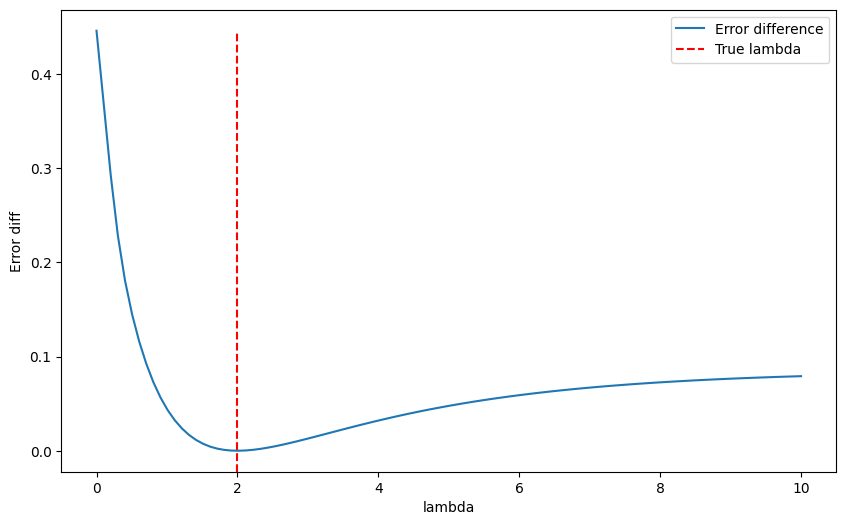

In [44]:
np.random.seed(1)
random.seed(10)
n8_ran = random_network_dist(8)
gamma_true = 2.
n8_ran_true = deepcopy(n8_ran)
n8_ran_true.UpdateGamma(gamma_true)
diffs = []
for gamma in np.linspace(0,10,100):
    n8_ran_gamma = deepcopy(n8_ran)
    n8_ran_gamma.UpdateGamma(gamma)
    #autocovs = true_var_autocov([0.15*np.identity(8)+0.35*n8_ran_true.w_mats[1].T-0.45*n8_ran_true.w_mats[2].T],1*np.identity(8),10)
    #diff = gamma_pred_diff([1,1],np.array([0.35,-0.45]),n8_ran_true.w_mats,n8_ran_gamma.w_mats,autocovs)/8
    autocovs = true_var_autocov([0.15*np.identity(8)+0.75*n8_ran_true.w_mats[1].T],1*np.identity(8),10)
    diff = gamma_pred_diff([1],np.array([0.75]),n8_ran_true.w_mats,n8_ran_gamma.w_mats,autocovs)
    diffs.append(diff/8)
plt.figure(figsize=(10,6))
plt.plot(np.linspace(0,10,100),diffs,label="Error difference")
plt.axvline(2,0,0.95,color="red",linestyle="--",label="True lambda")
plt.xlabel("lambda")
plt.ylabel("Error diff")
plt.legend()
plt.show()

# Bruma Application

In [2]:
def quantile(x, q):
    x = np.asarray(x,dtype=np.float64).reshape(-1)

    ind = np.isfinite(x)
    x = x[ind]

    if len(x) == 0:
        raise ValueError("No valid scores.")

    x = np.sort(x)

    q = min(max(float(q),0),1)

    if q <= 0:
        return x[0]
    if q >= 1:
        return x[-1]

    cw = np.arange(1,len(x)+1)/len(x)
    q_ind = np.searchsorted(cw,q,side="left")
    q_ind = min(q_ind,len(x)-1)

    return x[q_ind]

def interval_from_stat_errors(pred, errors, level=0.95, symmetric=True, beta_grid_size=101, eps=1e-12):
    errors = np.asarray(errors,dtype=np.float64)
    H,N = errors.shape

    weights = np.ones(H)
    weights = weights/np.sum(weights)

    error_cov = (errors.T*weights)@errors
    error_cov = 0.5*(error_cov+error_cov.T)

    error_sd = np.sqrt(np.maximum(np.diag(error_cov),eps))

    if symmetric:
        scores = np.abs(errors/error_sd.reshape(1,-1))
    else:
        scores = errors/error_sd.reshape(1,-1)

    if symmetric:
        c = quantile(scores.reshape(-1),level)

        half_width = c*error_sd

        lower = pred - half_width.reshape(1,-1)
        upper = pred + half_width.reshape(1,-1)

    else:
        alpha = 1.0 - level
        beta_grid = np.linspace(0,alpha,beta_grid_size)

        best_width = np.inf
        beta_hat = 0.0
        lower_q = None
        upper_q = None

        for beta in beta_grid:
            q_l = quantile(scores.reshape(-1),beta)
            q_u = quantile(scores.reshape(-1),1-alpha+beta)
            width = q_u - q_l

            if width < best_width:
                best_width = width
                beta_hat = beta
                lower_q = q_l
                upper_q = q_u

        lower = pred + lower_q*error_sd.reshape(1,-1)
        upper = pred + upper_q*error_sd.reshape(1,-1)

        half_width = 0.5*(upper[0] - lower[0])
        c = (lower_q,upper_q,beta_hat)

    return lower, upper, half_width, c, error_sd, error_cov

def interval_score(lower, upper, obs, level=0.95, symmetric=True, c=None, eps=1e-12):
    alpha = 1 - level

    if symmetric:
        lower_weight = 2 / alpha
        upper_weight = 2 / alpha
    else:
        beta = np.clip(c[2], eps, alpha - eps)
        lower_weight = 1 / beta
        upper_weight = 1 / (alpha - beta)

    return np.mean(
        (upper[0] - lower[0])
        + lower_weight * (lower[0] - obs) * (obs < lower[0])
        + upper_weight * (obs - upper[0]) * (obs > upper[0])
    )

In [3]:
files = [f"Brumadinho\\loc_{i}_pix.csv" for i in range(1, 7)]

pix_parts = []
loc_parts = []
nbhd_parts = []

for i, f in enumerate(files, start=1):
    data = np.genfromtxt(f, delimiter=",", dtype=np.double, skip_header=1)

    # rows except last 2 = time series
    # columns except first = pixels
    pix_i = data[:-2, 1:]

    # last 2 rows = Easting, Northing
    loc_i = data[-2:, 1:].T

    # Remove duplicate pixel columns within this file, keeping first occurrence
    _, keep_idx = np.unique(pix_i.T, axis=0, return_index=True)
    keep_idx = np.sort(keep_idx)

    pix_i = pix_i[:, keep_idx]
    loc_i = loc_i[keep_idx, :]

    # neighbourhood number from file number
    nbhd_i = np.full(len(keep_idx), i)

    pix_parts.append(pix_i)
    loc_parts.append(loc_i)
    nbhd_parts.append(nbhd_i)

pix_vts_full = np.hstack(pix_parts)
locs_full = np.vstack(loc_parts)
nbhds_full = np.concatenate(nbhd_parts)

In [4]:
def count_max_rlosd_by_nbhd(vts, nbhds, exclude_last=0, use_max=True):
    """
    vts shape: time x pixels
    Counts how many times each pixel has the maximum signed RLOSD
    within its Nbhd/sub-zone.
    """
    if exclude_last > 0:
        vts = vts[:-exclude_last, :]

    count_out = np.zeros(vts.shape[1], dtype=int)

    for nbhd in np.unique(nbhds):
        idx = np.where(nbhds == nbhd)[0]

        zone_vts = vts[:, idx]              # time x pixels_in_nbhd
        if use_max:
            zone_max = np.max(zone_vts, axis=1) # max per time point
        else:
            zone_max = np.min(zone_vts, axis=1)

        is_max = np.isclose(
            zone_vts,
            zone_max[:, None],
            rtol=0,
            atol=0
        )

        count_out[idx] = np.sum(is_max, axis=0)

    return count_out

counts_max_full = count_max_rlosd_by_nbhd(pix_vts_full,nbhds_full,exclude_last=4)
counts_min_full = count_max_rlosd_by_nbhd(pix_vts_full,nbhds_full,exclude_last=4,use_max=False)
counts_full = count_max_rlosd_by_nbhd(np.abs(pix_vts_full),nbhds_full,exclude_last=0,use_max=True)

In [5]:
keep_ind=np.logical_or(counts_max_full!=0,counts_min_full!=0)
pix_vts = pix_vts_full[:,keep_ind]
locs = locs_full[keep_ind]
nbhds = nbhds_full[keep_ind]
counts_max = counts_max_full[keep_ind]
counts_min = counts_min_full[keep_ind]
pix_vts.shape

(44, 128)

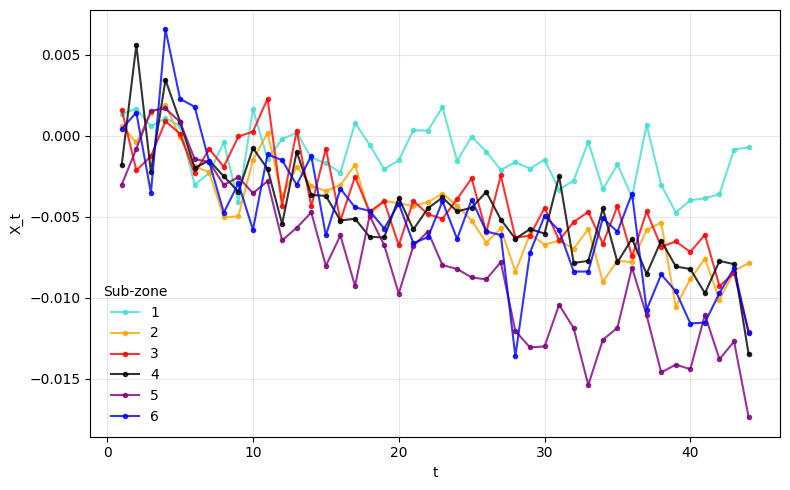

In [6]:
pix_vts = np.asarray(pix_vts)
nbhds = np.asarray(nbhds).ravel()

T, N = pix_vts.shape
zones = np.unique(nbhds)

zone_to_color = {
        1: "turquoise",
        2: "orange",
        3: "red",
        4: "black",
        5: "purple",
        6: "blue"
    }

time = np.arange(1, T + 1)

fig, ax = plt.subplots(figsize=(8, 5))

for z in zones:
    ind = nbhds == z
    zone_mean = np.mean(pix_vts[:, ind], axis=1)

    ax.plot(time, zone_mean, marker="o", markersize=3, linewidth=1.5, label=f"{z}",color=zone_to_color[z],alpha=0.8)

ax.set_xlabel("t")
ax.set_ylabel("X_t")
ax.legend(title="Sub-zone", frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
def get_edges_dists_dict_from_loc_count(locs,counts_min, counts_max,norm=2,thresh=100,offset=1):
    N = len(locs)
    edges,dists= {},{}
    for i in range(N):
        edges[i] = []
        dists[i] = []
        for j in range(N):
            if i != j:
                dist = np.linalg.norm((locs[i]-locs[j]),ord=norm)
                if dist <= thresh:
                    edges[i].append(j)
                    #dists[i].append(np.abs(np.log(counts[i]+1)-np.log(counts[j]+1))+1)
                    dists[i].append(np.sqrt((counts_max[i]-counts_max[j])**2 + (counts_min[i]-counts_min[j])**2)/np.max(np.sqrt(counts_min**2+counts_max**2))+offset)
                    #dists[i].append((np.abs(counts_max[i]-counts_max[j]) + np.abs(counts_min[i]-counts_min[j]))/np.max(np.abs(counts_min)+np.abs(counts_max))+1)
        dists[i] = np.array(dists[i])
    return edges,dists

## Get threshold using CV

In [8]:
sses_cv = []
thresh_list = [100,125,150,170,175,180,185,190,195,200,225,250,275,300]
for thresh in thresh_list:
    edges, dists = get_edges_dists_dict_from_loc_count(locs,counts_min, counts_max,2,thresh,1)
    net = Network(edges,dists,gamma=1.)
    p=1
    g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
    sses_cv.append(g.CV(net,pix_vts[5-p:40],10,seed,random=True,full_random=False))
sses_cv = np.array(sses_cv)

In [9]:
print("best_thresh="+str(thresh_list[np.argmin(sses_cv)]))

best_thresh=185


In [10]:
#output density
edges, dists = get_edges_dists_dict_from_loc_count(locs,counts_min,counts_max,2,185,1)
dist_count_net_1 = Network(edges,dists,gamma=1.)
dist_count_net_0 = Network(edges,dists,gamma=0.)
np.sum(dist_count_net_0.w_mats[1]!=0)/(128**2)

0.394287109375

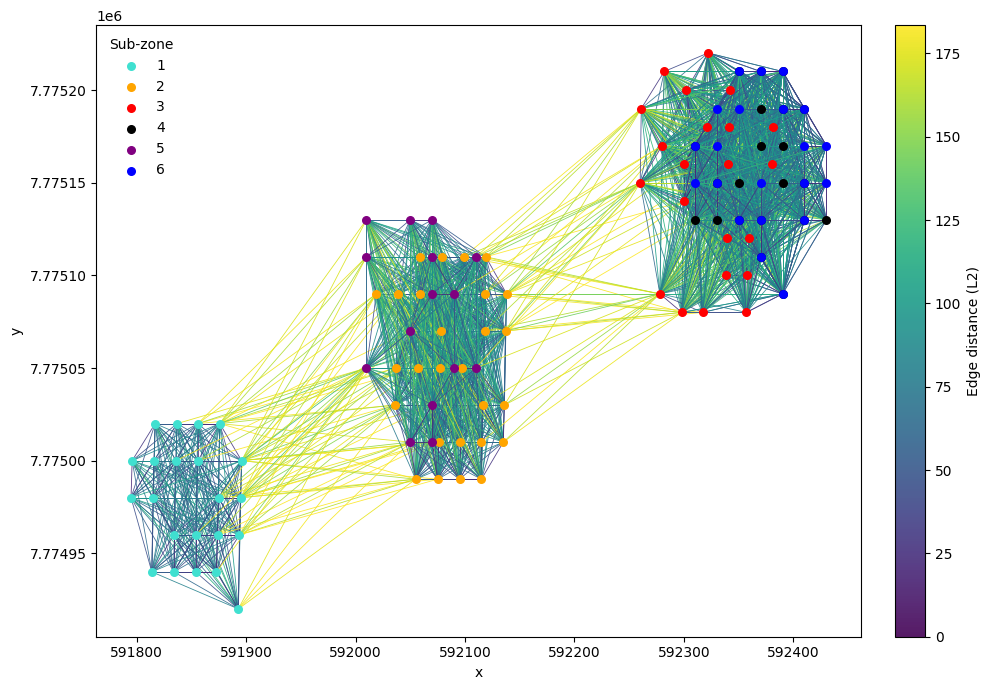

In [11]:
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

def threshold_network_edges(loc, thresh=200.0):
    loc = np.asarray(loc, dtype=float)
    N = loc.shape[0]
    diffs = loc[:, None, :] - loc[None, :, :]
    D2 = np.sum(diffs**2, axis=2)
    mask = (D2 < thresh**2) & (~np.eye(N, dtype=bool))
    iu, ju = np.triu_indices(N, k=1)
    edges = [(i, j) for i, j in zip(iu, ju) if mask[i, j]]
    return edges

def plot_threshold_network_colored_by_dist_and_zone(
    loc,
    edges,
    nbhds,
    node_size=30,
    lw=0.6
):
    loc = np.asarray(loc, dtype=float)
    nbhds = np.asarray(nbhds).ravel()
    zones = np.unique(nbhds)

    fig, ax = plt.subplots(figsize=(10, 7))

    segments = []
    dists = []
    for i, j in edges:
        p, q = loc[i], loc[j]
        segments.append([p, q])
        dists.append(np.linalg.norm(p - q))
    dists = np.asarray(dists)

    if len(segments) > 0:
        norm = Normalize(vmin=dists.min(), vmax=dists.max())
        lc = LineCollection(
            segments,
            array=dists,
            linewidths=lw,
            norm=norm,
            alpha=0.9,
            cmap="viridis"
        )
        ax.add_collection(lc)
        cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Edge distance (L2)")

    zone_to_color = {
        1: "turquoise",
        2: "orange",
        3: "red",
        4: "black",
        5: "purple",
        6: "blue"
    }

    for z in zones:
        ind = nbhds == z
        ax.scatter(
            loc[ind, 0],
            loc[ind, 1],
            s=node_size,
            color=zone_to_color[z],
            zorder=3,
            label=f"{z}"
        )

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(title="Sub-zone", frameon=False)
    fig.tight_layout()
    plt.show()

edges = threshold_network_edges(locs, thresh=185.0)
plot_threshold_network_colored_by_dist_and_zone(locs, edges, nbhds)

## Get optimal hyperparams using CV for each model

### Network models

In [12]:
sses_cv = []
thresh = 185
#edges, dists = get_edges_dists_dict_from_loc_count(locs,counts,2,thresh,1)
edges, dists = get_edges_dists_dict_from_loc_count(locs,counts_min,counts_max,norm=2,thresh=thresh,offset=1)
net = Network(edges,dists,gamma=1.)
for p in range(1,6):
    g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
    sses_cv.append(g.CV(net,pix_vts[5-p:40],10,seed,random=True,full_random=False))
    g = GNAR(p,[2 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
    sses_cv.append(g.CV(net,pix_vts[5-p:40],10,seed,random=True,full_random=False))
sses_cv = np.array(sses_cv)
print("best_p = " + str([1,2,3,4,5][np.argmin(sses_cv)//2]))
print("best_s = " + str(np.argmin(sses_cv)%2+1))

best_p = 2
best_s = 1


### AR-B (use p = 2 instead for better performance)

In [14]:
sses_cv = []
thresh = 185
edges, dists = get_edges_dists_dict_from_loc_count(locs,counts_min,counts_max,2,thresh,1)
net = Network(edges,dists,gamma=1.)
for p in range(1,6):
    g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=False,global_beta=True)
    sses_cv.append(g.CV(net,pix_vts[5-p:40],10,seed,random=True,full_random=False))
sses_cv = np.array(sses_cv)

print("best_p = " + str([1,2,3,4,5][np.argmin(sses_cv)//2]))

best_p = 1


### VARLasso

In [15]:
sses = []
alphas = np.linspace(1,10,10)*1e-6
for p in tqdm(range(1,6)):
    b=40
    for alpha in alphas:
        g = VARLasso(p,alpha=alpha,fit_intercept=True)
        sses.append(g.CV(pix_vts[5-p:b],10,seed=seed))
print("best_p = " + str([1,2,3,4,5][np.argmin(sses)//10]))
print("best_lambda = " + str(alphas[np.argmin(sses)%10]))

100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:37<00:00,  7.58s/it]

best_p = 3
best_lambda = 6e-06


## Fit and predict

### GNAR

In [16]:
p=2
b=40
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_1,pix_vts[:b])
print(g.validate(pix_vts[:b]))
print(g.validate(pix_vts[b-p:]))

0.06580189438637564
0.00942156163118915


### NAR

In [17]:
p=2
b=40
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])
print(g.validate(pix_vts[:b]))
print(g.validate(pix_vts[b-p:]))

0.06592198286003498
0.009475533781253754


### AR-A

In [18]:
p=2
b=40
g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])
print(g.validate(pix_vts[:b]))
print(g.validate(pix_vts[b-p:]))

0.07428538423564672
0.011801549877817202


### AR-B

In [19]:
p=2
b=40
g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=False,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])
print(g.validate(pix_vts[:b]))
print(g.validate(pix_vts[b-p:]))

0.06894884323831507
0.012449600764815683


### VARLasso

In [20]:
p=3
b=40
sses_fit = []
sses_pred = []
alpha=6e-06
g = VARLasso(p,alpha=alpha,fit_intercept=True)
g.fit(pix_vts[:b])
sses_fit.append(g.validate(pix_vts[:b]))
sses_pred.append(g.validate(pix_vts[b-p:]))
print(sses_fit[np.argmin(sses_pred)]) 
print(np.min(sses_pred))

0.04091445685195204
0.011827757420558721


### GNARID

#### Find the cap (see appendix)

In [21]:
p = 2
b = 40

g_bc = GNARID(
    p,
    [1 for i in range(p)],
    intercept=True,
    global_intercept=False,
    global_alpha=True,
    global_beta=True
)

g_bc.fit(
    dist_count_net_1,
    pix_vts[:b],
    grid_search=True,
    search_start=0,
    search_end=30,
    search_num=101,
    use_ls=True,
    l2_penal=0.
)

best_loss = min(g_bc.losses)

stage_n = max(g_bc.beta_order)
d_mats = np.asarray(dist_count_net_1.d_mats[:stage_n],dtype=float)
w_inf = np.zeros_like(d_mats)

for r in range(stage_n):
    for n in range(dist_count_net_1.size):
        ind = np.flatnonzero(d_mats[r,:,n]>0)

        if len(ind) == 0:
            continue

        dists = d_mats[r,ind,n]
        min_ind = ind[np.isclose(dists,np.min(dists))]
        w_inf[r,min_ind,n] = 1/len(min_ind)

network_inf = deepcopy(dist_count_net_1)
network_inf.w_mats[1:1+stage_n] = w_inf

g_inf = GNARID(
    p,
    [1 for i in range(p)],
    intercept=True,
    global_intercept=False,
    global_alpha=True,
    global_beta=True
)

g_inf.network = network_inf

X_inf = g_inf.transformVTS(pix_vts[:b])

if sparse.issparse(X_inf):
    X_inf = X_inf.toarray()

y = pix_vts[p:b,:].flatten("F")
coefs_inf = np.linalg.lstsq(X_inf,y,rcond=None)[0]
loss_inf = np.sum((y-X_inf@coefs_inf)**2)

gap = loss_inf-best_loss

gamma_cap = g_bc.gamma_cap(
    dist_count_net_1,
    pix_vts[:b],
    gap=gap,
    gap_rtol=1e-8,
    gamma_tol=1e-6,
    doubling_init=30
)

print("best loss:",best_loss)
print("loss at infinity:",loss_inf)
print("gap:",gap)
print("gamma cap:",gamma_cap)
print(g_bc.gamma_cap_info)

best loss: 0.06539040653182537
loss at infinity: 0.06964003716087298
gap: 0.00424963062904761
gamma cap: 141.5731778740883
{'loss_inf': 0.06964003716087298, 'gap': 0.00424963062904761, 'safety_margin': 1e-08, 'usable_gap': 0.00424962062904761, 'sigma_min_limit': 0.18659676311783147, 'improvement_bound_at_cap': 0.004249620614836319, 'certified': True}


#### Fit

7.5


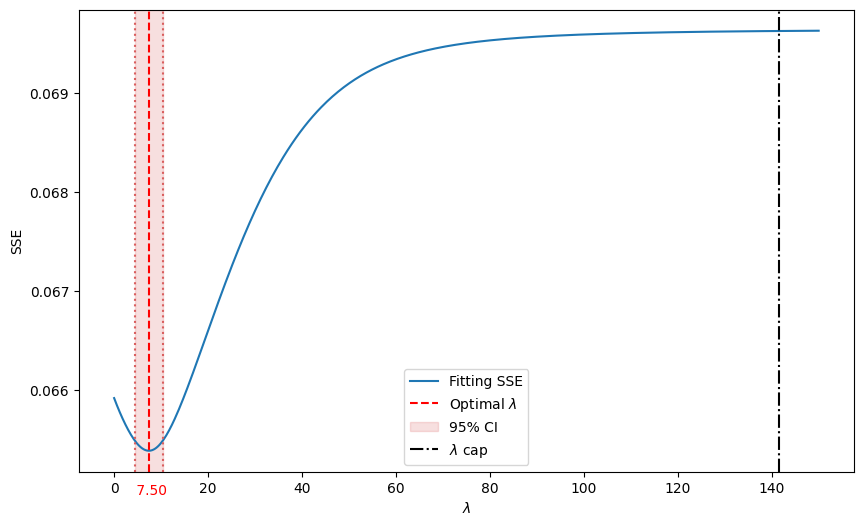

0.06539040653182537
0.009172991758319867


In [22]:
p=2
b = 40
g_bc = GNARID(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g_bc.fit(dist_count_net_1,pix_vts[:b],grid_search=True,search_start=0,search_end=150,search_num=501,use_ls=True,l2_penal=0.)
g_bc.compute_ci()
print(g_bc.gamma)
plt.figure(figsize=(10, 6))
plt.plot(g_bc.gammas,g_bc.losses,label="Fitting SSE")
plt.axvline(x=g_bc.gamma,ymin=0,ymax=1,color="red",linestyle='--',label=r"Optimal $\lambda$")

ci_low, ci_high = g_bc.CI[-1]
plt.axvspan(ci_low, ci_high, alpha=0.2, color="#d95f5f", label="95% CI")
plt.axvline(x=ci_low, linestyle=":", color="#d95f5f")
plt.axvline(x=ci_high, linestyle=":",color="#d95f5f")

plt.text(g_bc.gamma, -0.025, f"{g_bc.gamma: .2f}", color='red',
         ha='center', va='top', fontsize=10, transform=plt.gca().get_xaxis_transform())
#plt.title("Fitting SSE vs lambda")
plt.xlabel(r"$\lambda$")
plt.ylabel("SSE")
plt.axvline(x=gamma_cap,color="black",linestyle="-.",label=r"$\lambda$ cap")
plt.legend()
plt.show()
print(g_bc.validate(pix_vts[:b]))
print(g_bc.validate(pix_vts[b-p:]))

#### A closer look

7.5


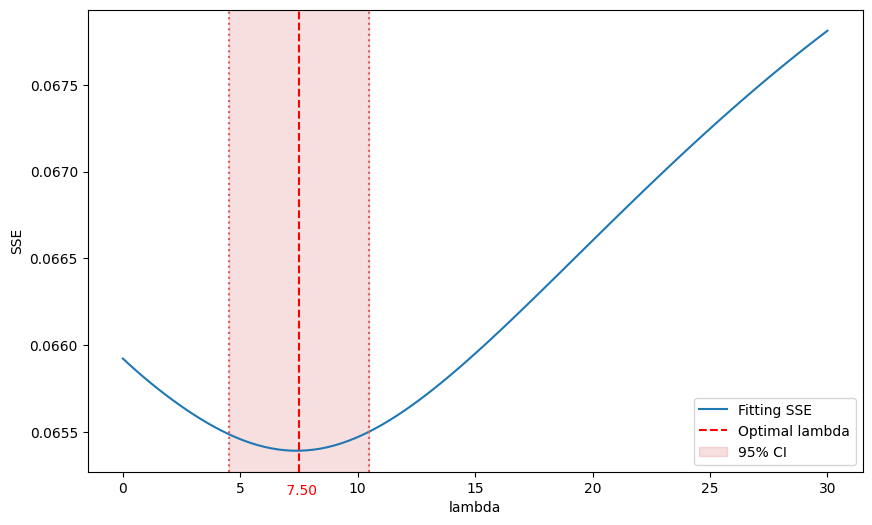

0.06539040653182537
0.009172991758319867


In [23]:
p=2
b = 40
g_bc = GNARID(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g_bc.fit(dist_count_net_1,pix_vts[:b],grid_search=True,search_start=0,search_end=30,search_num=101,use_ls=True,l2_penal=0.)
g_bc.compute_ci()
print(g_bc.gamma)
plt.figure(figsize=(10, 6))
plt.plot(g_bc.gammas,g_bc.losses,label="Fitting SSE")
plt.axvline(x=g_bc.gamma,ymin=0,ymax=1,color="red",linestyle='--',label="Optimal lambda")

ci_low, ci_high = g_bc.CI[-1]
plt.axvspan(ci_low, ci_high, alpha=0.2, color="#d95f5f", label="95% CI")
plt.axvline(x=ci_low, linestyle=":", color="#d95f5f")
plt.axvline(x=ci_high, linestyle=":",color="#d95f5f")

plt.text(g_bc.gamma, -0.025, f"{g_bc.gamma: .2f}", color='red',
         ha='center', va='top', fontsize=10, transform=plt.gca().get_xaxis_transform())
#plt.title("Fitting SSE vs lambda")
plt.xlabel("lambda")
plt.ylabel("SSE")
plt.legend()
plt.show()
print(g_bc.validate(pix_vts[:b]))
print(g_bc.validate(pix_vts[b-p:]))

#### Alphas and betas

In [15]:
g_bc.coefs[:4]

array([0.07144738, 0.37944525, 0.07626602, 0.35529086])

#### Intercepts

In [13]:
for i in range(1,7):
    print((g_bc.coefs[4:][nbhds==i]).mean())

6.3800089317294125e-06
-0.0002529705860641205
-0.00022825291880618564
-0.000885307302961294
-0.0028787278937291634
-0.001321172294572869


## Forecast intervals

### GNARID

In [47]:
p=2
b = 40
g_bc = GNARID(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
errors_gnarid = g_bc.loo(dist_count_net_1,pix_vts[:b],grid_search=True,search_start=0,search_end=30,search_num=101,use_ls=True,l2_penal=0.)

g_bc = GNARID(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g_bc.fit(dist_count_net_1,pix_vts[:b],grid_search=True,search_start=0,search_end=30,search_num=101,use_ls=True,l2_penal=0.)

pred_gnarid = g_bc.transformVTS(pix_vts[b-p:])@g_bc.coefs
pred_gnarid = np.reshape(pred_gnarid,(-1,g_bc.network.size),order="F")
print(np.sum((pix_vts[b:]-pred_gnarid)**2))

lower_gnarid_arr = np.zeros((4,pred_gnarid.shape[1]))
upper_gnarid_arr = np.zeros((4,pred_gnarid.shape[1]))
score_gnarid_arr = np.zeros(4)
coverage_gnarid_arr = np.zeros(4)
width_gnarid_arr = np.zeros(4)

for i in range(4):
    lower_gnarid, upper_gnarid, half_width_gnarid, c_gnarid, error_sd_gnarid, error_cov_gnarid = interval_from_stat_errors(pred_gnarid[i:i+1],errors_gnarid)

    obs = pix_vts[b+i:b+i+1]

    lower_gnarid_arr[i] = lower_gnarid[0]
    upper_gnarid_arr[i] = upper_gnarid[0]
    score_gnarid_arr[i] = interval_score(lower_gnarid,upper_gnarid,obs)
    coverage_gnarid_arr[i] = np.mean((obs[0] >= lower_gnarid[0]) & (obs[0] <= upper_gnarid[0]))
    width_gnarid_arr[i] = np.mean(upper_gnarid[0] - lower_gnarid[0])

print("LOO:", np.mean(errors_gnarid**2))
print("mean coverage:", np.mean(coverage_gnarid_arr))
print("mean width:", np.mean(width_gnarid_arr))
print("mean score:", np.mean(score_gnarid_arr))

0.009172991758319867
LOO: 1.4411312656115665e-05
mean coverage: 0.923828125
mean width: 0.014351037960053142
mean score: 0.01957786143985448


### GNAR

In [75]:
p=2
b=40
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
errors_gnar = g.CV(dist_count_net_1,pix_vts[:b],b-p,seed=0,random=False,output_errors=True)

g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_1,pix_vts[:b])

pred_gnar = g.transformVTS(pix_vts[b-p:])@g.coefs
pred_gnar = np.reshape(pred_gnar,(-1,g.network.size),order="F")
print(np.sum((pix_vts[b:]-pred_gnar)**2))

lower_gnar_arr = np.zeros((4,pred_gnar.shape[1]))
upper_gnar_arr = np.zeros((4,pred_gnar.shape[1]))
score_gnar_arr = np.zeros(4)
coverage_gnar_arr = np.zeros(4)
width_gnar_arr = np.zeros(4)

for i in range(4):
    lower_gnar, upper_gnar, half_width_gnar, c_gnar, error_sd_gnar, error_cov_gnar = interval_from_stat_errors(pred_gnar[i:i+1],errors_gnar)

    obs = pix_vts[b+i:b+i+1]

    lower_gnar_arr[i] = lower_gnar[0]
    upper_gnar_arr[i] = upper_gnar[0]
    score_gnar_arr[i] = interval_score(lower_gnar,upper_gnar,obs)
    coverage_gnar_arr[i] = np.mean((obs[0] >= lower_gnar[0]) & (obs[0] <= upper_gnar[0]))
    width_gnar_arr[i] = np.mean(upper_gnar[0] - lower_gnar[0])

print("LOO:", np.mean(errors_gnar**2))
print("mean coverage:", np.mean(coverage_gnar_arr))
print("mean width:", np.mean(width_gnar_arr))
print("mean score:", np.mean(score_gnar_arr))

0.00942156163118915
LOO: 1.4501959960005801e-05
mean coverage: 0.9296875
mean width: 0.014454402602772969
mean score: 0.019774507357230176


### NAR

In [49]:
p=2
b=40
g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
errors_nar = g.CV(dist_count_net_0,pix_vts[:b],b-p,seed=0,random=False,output_errors=True)

g = GNAR(p,[1 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])

pred_nar = g.transformVTS(pix_vts[b-p:])@g.coefs
pred_nar = np.reshape(pred_nar,(-1,g.network.size),order="F")
print(np.sum((pix_vts[b:]-pred_nar)**2))

lower_nar_arr = np.zeros((4,pred_nar.shape[1]))
upper_nar_arr = np.zeros((4,pred_nar.shape[1]))
score_nar_arr = np.zeros(4)
coverage_nar_arr = np.zeros(4)
width_nar_arr = np.zeros(4)

for i in range(4):
    lower_nar, upper_nar, half_width_nar, c_nar, error_sd_nar, error_cov_nar = interval_from_stat_errors(pred_nar[i:i+1],errors_nar)

    obs = pix_vts[b+i:b+i+1]

    lower_nar_arr[i] = lower_nar[0]
    upper_nar_arr[i] = upper_nar[0]
    score_nar_arr[i] = interval_score(lower_nar,upper_nar,obs)
    coverage_nar_arr[i] = np.mean((obs[0] >= lower_nar[0]) & (obs[0] <= upper_nar[0]))
    width_nar_arr[i] = np.mean(upper_nar[0] - lower_nar[0])

print("LOO:", np.mean(errors_nar**2))
print("mean coverage:", np.mean(coverage_nar_arr))
print("mean width:", np.mean(width_nar_arr))
print("mean score:", np.mean(score_nar_arr))

0.009475533781253754
LOO: 1.4529534439576434e-05
mean coverage: 0.9296875
mean width: 0.014545318849453277
mean score: 0.019825351963047792


### AR-A

In [50]:
p=2
b=40
g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
errors_arg = g.CV(dist_count_net_0,pix_vts[:b],b-p,seed=0,random=False,output_errors=True)

g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=True,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])

pred_arg = g.transformVTS(pix_vts[b-p:])@g.coefs
pred_arg = np.reshape(pred_arg,(-1,g.network.size),order="F")
print(np.sum((pix_vts[b:]-pred_arg)**2))

lower_arg_arr = np.zeros((4,pred_arg.shape[1]))
upper_arg_arr = np.zeros((4,pred_arg.shape[1]))
score_arg_arr = np.zeros(4)
coverage_arg_arr = np.zeros(4)
width_arg_arr = np.zeros(4)

for i in range(4):
    lower_arg, upper_arg, half_width_arg, c_arg, error_sd_arg, error_cov_arg = interval_from_stat_errors(pred_arg[i:i+1],errors_arg)

    obs = pix_vts[b+i:b+i+1]

    lower_arg_arr[i] = lower_arg[0]
    upper_arg_arr[i] = upper_arg[0]
    score_arg_arr[i] = interval_score(lower_arg,upper_arg,obs)
    coverage_arg_arr[i] = np.mean((obs[0] >= lower_arg[0]) & (obs[0] <= upper_arg[0]))
    width_arg_arr[i] = np.mean(upper_arg[0] - lower_arg[0])

print("LOO:", np.mean(errors_arg**2))
print("mean coverage:", np.mean(coverage_arg_arr))
print("mean width:", np.mean(width_arg_arr))
print("mean score:", np.mean(score_arg_arr))

0.011801549877817202
LOO: 1.625603755856625e-05
mean coverage: 0.8828125
mean width: 0.015170601922797063
mean score: 0.023283212466733046


### AR-B

In [51]:
p=2
b=40
g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=False,global_beta=True)
errors_ar = g.CV(dist_count_net_0,pix_vts[:b],b-p,seed=0,random=False,output_errors=True)

g = GNAR(p,[0 for i in range(p)],intercept=True,global_intercept=False,global_alpha=False,global_beta=True)
g.fit(dist_count_net_0,pix_vts[:b])

pred_ar = g.transformVTS(pix_vts[b-p:])@g.coefs
pred_ar = np.reshape(pred_ar,(-1,g.network.size),order="F")
print(np.sum((pix_vts[b:]-pred_ar)**2))

lower_ar_arr = np.zeros((4,pred_ar.shape[1]))
upper_ar_arr = np.zeros((4,pred_ar.shape[1]))
score_ar_arr = np.zeros(4)
coverage_ar_arr = np.zeros(4)
width_ar_arr = np.zeros(4)

for i in range(4):
    lower_ar, upper_ar, half_width_ar, c_ar, error_sd_ar, error_cov_ar = interval_from_stat_errors(pred_ar[i:i+1],errors_ar)

    obs = pix_vts[b+i:b+i+1]

    lower_ar_arr[i] = lower_ar[0]
    upper_ar_arr[i] = upper_ar[0]
    score_ar_arr[i] = interval_score(lower_ar,upper_ar,obs)
    coverage_ar_arr[i] = np.mean((obs[0] >= lower_ar[0]) & (obs[0] <= upper_ar[0]))
    width_ar_arr[i] = np.mean(upper_ar[0] - lower_ar[0])

print("LOO:", np.mean(errors_ar**2))
print("mean coverage:", np.mean(coverage_ar_arr))
print("mean width:", np.mean(width_ar_arr))
print("mean score:", np.mean(score_ar_arr))

0.012449600764815683
LOO: 1.7060857178660584e-05
mean coverage: 0.88671875
mean width: 0.015389992827765053
mean score: 0.02350677687003353


### VARLasso

In [52]:
p=3
b=40
alpha = 6e-06
vl = VARLasso(p,alpha=alpha,fit_intercept=True)
errors_vl = vl.CV(pix_vts[:b],b-p,seed=0,random=False,output_errors=True)

vl = VARLasso(p,alpha=alpha,fit_intercept=True)
vl.fit(pix_vts[:b])

pred_vl = vl.predict(pix_vts[b-p:-1])
print(np.sum((pix_vts[b:]-pred_vl)**2))

lower_vl_arr = np.zeros((4,pred_vl.shape[1]))
upper_vl_arr = np.zeros((4,pred_vl.shape[1]))
score_vl_arr = np.zeros(4)
coverage_vl_arr = np.zeros(4)
width_vl_arr = np.zeros(4)

for i in range(4):
    lower_vl, upper_vl, half_width_vl, c_vl, error_sd_vl, error_cov_vl = interval_from_stat_errors(pred_vl[i:i+1],errors_vl)

    obs = pix_vts[b+i:b+i+1]

    lower_vl_arr[i] = lower_vl[0]
    upper_vl_arr[i] = upper_vl[0]
    score_vl_arr[i] = interval_score(lower_vl,upper_vl,obs)
    coverage_vl_arr[i] = np.mean((obs[0] >= lower_vl[0]) & (obs[0] <= upper_vl[0]))
    width_vl_arr[i] = np.mean(upper_vl[0] - lower_vl[0])

print("LOO:", np.mean(errors_vl**2))
print("mean coverage:", np.mean(coverage_vl_arr))
print("mean width:", np.mean(width_vl_arr))
print("mean score:", np.mean(score_vl_arr))

0.011827757420558721
LOO: 1.5231804826045719e-05
mean coverage: 0.87890625
mean width: 0.014783722252259393
mean score: 0.02456952118725069


### Plot GNARID intervals

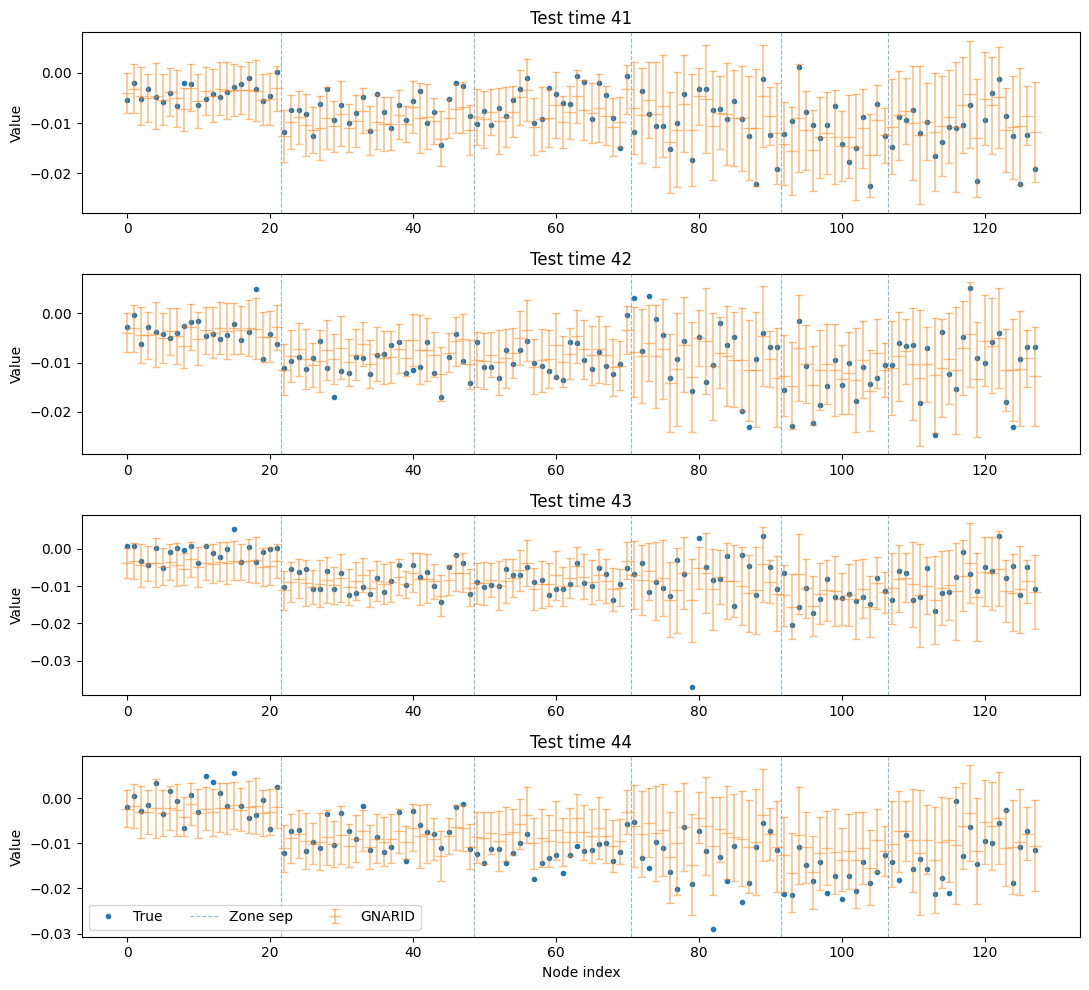

In [71]:
times = np.arange(b,b+4)
zone_boundaries = np.where(np.diff(nbhds) != 0)[0] + 0.5

fig, axes = plt.subplots(4,1,figsize=(11,10),sharex=False)

for i in range(4):
    obs = pix_vts[b+i]
    x = np.arange(len(obs))

    ax = axes[i]

    ax.plot(x,obs,marker=".",linestyle="",label="True")

    yerr_gnarid = np.vstack((pred_gnarid[i]-lower_gnarid_arr[i], upper_gnarid_arr[i]-pred_gnarid[i]))
    ax.errorbar(x,pred_gnarid[i],yerr=yerr_gnarid,fmt="_",linestyle="",capsize=3,markersize=8,linewidth=1.2,label="GNARID",alpha=0.5)

    #yerr_gnar = np.vstack((pred_gnar[i]-lower_gnar_arr[i], upper_gnar_arr[i]-pred_gnar[i]))
    #ax.errorbar(x,pred_gnar[i],yerr=yerr_gnar,fmt="_",linestyle="",capsize=3,markersize=8,linewidth=1.2,label="GNAR",alpha=0.5)

    #yerr_ar = np.vstack((pred_ar[i]-lower_ar_arr[i], upper_ar_arr[i]-pred_ar[i]))
    #ax.errorbar(x,pred_ar[i],yerr=yerr_ar,fmt="_",linestyle="",capsize=3,markersize=8,linewidth=1.2,label="AR",alpha=0.5)

    for j,z in enumerate(zone_boundaries):
        ax.axvline(z,linestyle="--",linewidth=0.8,alpha=0.5,label="Zone sep" if i == 3 and j == 0 else None)

    ax.set_title(f"Test time {times[i]+1}")
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Node index")
axes[-1].legend(ncol=4)
plt.tight_layout()
plt.show()